# Activity Data Visualization

This notebook contains the process followed to visualize activity.

## 1 Data

The data comes from a Garmin Forerunner 245 watch that has recorded activities for around 5 years. It can be downloaded using the Garmin Connect's dashpage into a CSV format.

### 1.1 Reading data.

The data is loaded from the `Activities.csv` file that should be located in the same directory as this notebook.

In [1]:
import pandas as pd

df = pd.read_csv("./data/activities.csv")

df.head()

,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,...,Steps,Total Reps,Total Sets,Decompression,Best Lap Time,Number of Laps,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Walking,2026-03-19 20:04:39,False,Majadahonda Walking,6.41,472,01:06:17,120,150,3.1,...,"7,482",--,--,No,00:04:16.7,7,01:06:04,01:06:17,677,750
1,Walking,2026-03-18 10:46:40,False,Majadahonda Walking,1.64,103,00:17:40,124,142,1.0,...,"1,968",--,--,No,00:06:52.3,2,00:17:40,00:17:40,679,722
2,Trail Running,2026-03-18 10:13:00,False,Majadahonda - R20 W04 (02:00),3.48,268,00:33:08,140,166,2.6,...,"4,230",--,--,No,00:00:07.8,17,00:33:07,00:33:08,716,750
3,Walking,2026-03-18 10:02:07,False,Majadahonda Walking,1.01,82,00:10:08,138,158,2.0,...,"1,210",--,--,No,00:00:02.1,2,00:10:07,00:10:08,689,722
4,Walking,2026-03-17 10:59:00,False,Majadahonda Walking,1.01,65,00:11:00,126,134,0.7,...,"1,204",--,--,No,00:00:05.5,2,00:10:58,00:11:00,679,715


### 1.2 Understanding the data

By using the function `df.info()` we can see dataframe column information, which showcases the following:

- 31 different columns.
- Default types set to `str`, `bool`, `float64`, `int64`.
- Some columns seem to have the wrong data type (`Distance` having `str` even most of its values are numeric).

| \# | Column                 | Non-Null Count | Dtype   |
|----|------------------------|----------------|---------|  
| 0  | Activity Type          | 180 non-null   | str     |
| 1  | Date                   | 180 non-null   | str     |
| 2  | Favorite               | 180 non-null   | bool    |
| 3  | Title                  | 180 non-null   | str     |
| 4  | Distance               | 180 non-null   | str     |
| 5  | Calories               | 180 non-null   | str     |
| 6  | Time                   | 180 non-null   | str     |
| 7  | Avg HR                 | 180 non-null   | str     |
| 8  | Max HR                 | 180 non-null   | str     |
| 9  | Aerobic TE             | 180 non-null   | str     |
| 10 | Avg Cadence            | 180 non-null   | str     |
| 11 | Max Cadence            | 180 non-null   | str     |
| 12 | Avg Pace               | 180 non-null   | str     |
| 13 | Best Pace              | 180 non-null   | str     |
| 14 | Total Ascent           | 180 non-null   | str     |
| 15 | Total Descent          | 180 non-null   | str     |
| 16 | Avg Stride Length      | 180 non-null   | str     |
| 17 | Training Stress Score® | 180 non-null   | float64 |
| 18 | Total Strokes          | 180 non-null   | str     |
| 19 | Avg. Swolf             | 180 non-null   | str     |
| 20 | Avg Stroke Rate        | 180 non-null   | str     |
| 21 | Steps                  | 180 non-null   | str     |
| 22 | Total Reps             | 180 non-null   | str     |
| 23 | Total Sets             | 180 non-null   | str     |
| 24 | Decompression          | 180 non-null   | str     |
| 25 | Best Lap Time          | 180 non-null   | str     |
| 26 | Number of Laps         | 180 non-null   | int64   |
| 27 | Moving Time            | 180 non-null   | str     |
| 28 | Elapsed Time           | 180 non-null   | str     |
| 29 | Min Elevation          | 180 non-null   | str     |
| 30 | Max Elevation          | 180 non-null   | str     |



In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Activity Type           180 non-null    str    
 1   Date                    180 non-null    str    
 2   Favorite                180 non-null    bool   
 3   Title                   180 non-null    str    
 4   Distance                180 non-null    str    
 5   Calories                180 non-null    str    
 6   Time                    180 non-null    str    
 7   Avg HR                  180 non-null    str    
 8   Max HR                  180 non-null    str    
 9   Aerobic TE              180 non-null    str    
 10  Avg Cadence             180 non-null    str    
 11  Max Cadence             180 non-null    str    
 12  Avg Pace                180 non-null    str    
 13  Best Pace               180 non-null    str    
 14  Total Ascent            180 non-null    str    
 15  

#### 1.2.1 AI Analysis

I gave AI the following prompt to create me a table indicating it's suggested analysis of the data:

> Read the linked CSV file and analyze it, create a table with the following fields:
> 
> - Nº: Column number.
> - Column: Column name.
> - Description: Content description (what the data in the column usually looks like, excluding null indicators).
> - Null indicator: Indicator that seems to be used for when data is null.
> - Data type: Suggested data type to be used when reading CSV in Pandas.
qwen3.5-9b

The AI then printed me the following table:

| Nº | Column               | Description                                                                                   | Null indicator | Data type         |
|----|----------------------|-----------------------------------------------------------------------------------------------|----------------|------------------|
| 1  | Activity Type        | Indicates the type of activity (e.g., Walking, Trail Running)                                  | --             | categorical       |
| 2  | Date                 | Timestamp indicating when the activity started                                                 | --             | datetime64[ns]    |
| 3  | Favorite             | Boolean value indicating if the activity is marked as a favorite                               | false          | boolean           |
| 4  | Title                | Name of the activity                                                                           | "Majadahonda Walking", etc. | string |
| 5  | Distance             | Total distance covered during the activity                                                      | --             | float64           |
| 6  | Calories             | Number of calories burned during the activity                                                   | --             | int64             |
| 7  | Time                 | Duration of the activity (hh:mm:ss)                                                            | --             | timedelta64      |
| 8  | Avg HR               | Average heart rate during the activity                                                          | --             | float64           |
| 9  | Max HR               | Maximum heart rate reached during the activity                                                  | --             | int64             |
| 10 | Aerobic TE           | Total energy expenditure from aerobic exercise                                                  | --             | float64           |
| 11 | Avg Cadence          | Average cadence (number of steps per minute)                                                    | --             | int64             |
| 12 | Max Cadence          | Maximum cadence reached during the activity                                                     | --             | int64             |
| 13 | Avg Pace            | Average pace of the activity in minutes per kilometer                                           | --             | timedelta64      |
| 14 | Best Pace           | Best pace achieved during the activity                                                           | --             | timedelta64      |
| 15 | Total Ascent         | Total ascent climbed during the activity                                                        | --             | float64           |
| 16 | Total Descent        | Total descent descended during the activity                                                     | --             | float64           |
| 17 | Avg Stride Length    | Average stride length during the activity                                                       | --             | float64           |
| 18 | Training Stress Score®| A score indicating overall stress on the body due to exercise                                 | --             | float64           |
| 19 | Total Strokes        | Number of strokes if applicable (swimming)                                                     | --             | int64             |
| 20 | Avg. Swolf           | Average swimming efficiency metric (synchronization of stroke and frequency)                    | --             | float64           |
| 21 | Avg Stroke Rate      | Average number of strokes per minute                                                            | --             | float64           |
| 22 | Steps                | Total number of steps taken during the activity                                                 | --             | int64             |
| 23 | Total Reps           | Total repetitions if applicable (strength training)                                            | --             | int64             |
| 24 | Total Sets           | Total sets if applicable (strength training)                                                    | --             | int64             |
| 25 | Decompression        | Indicates whether decompression was needed                                                      | No             | boolean           |
| 26 | Best Lap Time        | Best lap time achieved during the activity                                                     | "00:04:16.7", etc. | timedelta64      |
| 27 | Number of Laps       | Total number of laps completed                                                                 | --             | int64             |
| 28 | Moving Time          | The total moving time (excluding pauses)                                                        | "01:06:04"     | timedelta64      |
| 29 | Elapsed Time         | Total elapsed time including stops                                                             | "01:06:17"     | timedelta64      |
| 30 | Min Elevation        | Minimum elevation reached during the activity                                                   | --             | int64             |
| 31 | Max Elevation        | Maximum elevation reached during the activity                                                   | --             | int64             |

Although not perfect, this gives us a good starting point on cleaning up the data and having it be more readable. Some mistakes we can catch at first glanse from the analysis are the following:

- **Favorite:** `false` isn't necessarily a Null value, just means it hasn't been indicated.
- **Title:** Null indicator is clearly wrong (`"Majadahonda Walking"`is just a commonly used title).
- **Aerobic TE:** Didn't expect AI to get it right, it is [calculated based off training condition](https://www.garmin.com/en-US/garmin-technology/running-science/physiological-measurements/aerobic-training-effect/).
- **Decompression:** No doesn't necessarily mean its Null, just means it hasn't been indicated, could be changed to `True` and `False`.
- **Best Lap Time, Moving Time, Elapsed Time:** Null indicator clearly wrong, just a common time given.

Based off of the data analysis and browsing the CSV file

### 1.3 Cleaning data

Below are a couple steps taken to clean the data based off of the analysis the AI did.

In [3]:
# 1. Delete unused columns.
# These are columns which will not be used for further analysis and/or viz
try:
    df = df.drop(columns=[
        'Favorite', 'Total Reps', 'Total Sets', 'Decompression', 'Best Lap Time',
        'Avg Cadence', 'Total Strokes', 'Avg. Swolf', 'Elapsed Time', 
        'Number of Laps', 'Avg Stroke Rate', 'Avg Stride Length', 'Max Cadence',
        'Training Stress Score®'
        ])
except:
    print("ERROR: Couldn't drop columns, maybe you've already dropped them?")

# 2. Change Null indicator for None values when applicable.
# This will standardize values easier
for column in df.columns:
    df[column] = df[column].map(lambda x: None if x == '--' else x)

df.head()

# 3. Clean data
import re
import numpy as np

def clean_commas(x):
    if pd.isna(x):
        return np.nan
    return float(str(x).replace(",", ""))

# Remove commas from numbers (used to indicate thousanth place)
for col_name in ["Calories", "Steps", "Min Elevation", "Max Elevation"]:
    df[col_name] = df[col_name].apply(clean_commas)

# If data is not in correct format, switch it for None (for timedelta format)
def clean_timedelta(col: pd.Series, format="hhmmss") -> pd.Series:
    pattern = None
    if format == "mmss":  # MM:SS Format (Pace columns)
        pattern = re.compile(r"^\d{1,2}:\d{2}$")
    elif format == "hhmmss":  # HH:MM:SS (Time columns)
        pattern = re.compile(r"^\d{2}:\d{2}:\d{2}$")
    
    # keep only matching strings, else None
    clean_col =  col.map(lambda s: str(s) if pattern.match(str(s)) else None)
    return clean_col.astype("string")

df["Avg Pace"] = clean_timedelta(df["Avg Pace"], "mmss")
df["Best Pace"] = clean_timedelta(df["Best Pace"], "mmss")
df["Moving Time"] = clean_timedelta(df["Moving Time"], "hhmmss")
    
# 4. Change column type to correct one.
df["Activity Type"] = df["Activity Type"].astype("category")
df["Date"] = pd.to_datetime(df["Date"])
df["Distance"] = pd.to_numeric(df["Distance"])
df["Calories"] = pd.to_numeric(df["Calories"]).astype("Int64")
df["Time"] = pd.to_timedelta(df["Time"])
df["Avg HR"] = pd.to_numeric(df["Avg HR"], errors='coerce').astype("Int64")
df["Max HR"] = pd.to_numeric(df["Max HR"], errors='coerce').astype("Int64") 
df["Aerobic TE"] = pd.to_numeric(df["Aerobic TE"])
df["Avg Pace"] = pd.to_timedelta("00:" + df["Avg Pace"].astype("string"), errors="coerce")
df["Best Pace"] = pd.to_timedelta("00:" + df["Best Pace"].astype("string"), errors="coerce")
df["Total Ascent"] = pd.to_numeric(df["Total Ascent"])
df["Total Descent"] = pd.to_numeric(df["Total Descent"])
df["Steps"] = pd.to_numeric(df["Steps"]).astype("Int64")
df["Moving Time"] = pd.to_timedelta(df["Moving Time"], errors="coerce")
df["Min Elevation"] = pd.to_numeric(df["Min Elevation"]).astype("Int64")
df["Max Elevation"] = pd.to_numeric(df["Max Elevation"]).astype("Int64")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype          
---  ------         --------------  -----          
 0   Activity Type  180 non-null    category       
 1   Date           180 non-null    datetime64[us] 
 2   Title          180 non-null    str            
 3   Distance       179 non-null    float64        
 4   Calories       180 non-null    Int64          
 5   Time           180 non-null    timedelta64[us]
 6   Avg HR         178 non-null    Int64          
 7   Max HR         178 non-null    Int64          
 8   Aerobic TE     179 non-null    float64        
 9   Avg Pace       174 non-null    timedelta64[us]
 10  Best Pace      174 non-null    timedelta64[us]
 11  Total Ascent   159 non-null    float64        
 12  Total Descent  158 non-null    float64        
 13  Steps          175 non-null    Int64          
 14  Moving Time    165 non-null    timedelta64[us]
 15  Min Elevation  16

### Question-Specific Feature Engineering

For some of the questions being asked about the dataset, new fields need to be created to be able to answer specific questions.

- `Week` and `Year` can be extracted from the `df['Date']` column.
- Simplify different running activities to the same `Activity Type`.
- `Intensity` can be extraced from `Avg HR` having 140 bpm as the differentiator between `Moderate` and `Vigorous` activity.
- `Location` can be extracted from `Title` but I'm unsure of the regex pattern that would have to be used, since it's a complex one due to title being in many different formats.

In [5]:
# Week/Year extraction from Date
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week

# Simplify Running activity type
df['Activity Type'] = df['Activity Type'].replace({
    'Treadmill Running': 'Running',
    'Trail Running': 'Running'
})
# Convert to category & drop unused (zeros gone forever)
df['Activity Type'] = df['Activity Type'].astype('category').cat.remove_unused_categories()

# Intensity (WHO Guidelines):
df['Intensity'] = pd.cut(
    df['Avg HR'], bins=[-np.inf, 140, np.inf], 
    labels=['Moderate', 'Vigorous']
)

df['Time_min'] = df['Time'].dt.total_seconds() / 60

# Vectorized WHO_equiv (fixes error)
df['WHO_equiv'] = np.where(df['Intensity'] == 'Vigorous', 
                           df['Time_min'] * 2, df['Time_min'])

df['Activity_Group'] = df['Activity Type'].apply(
    lambda x: 'Strength/Cardio' if x in ['Strength', 'Pilates'] else 'Endurance')

weekly = df.groupby(['Year', 'Week', 'Intensity', 'Activity_Group'])['WHO_equiv'].sum().reset_index()
print(weekly.head())  # Verify

   Year  Week Intensity Activity_Group   WHO_equiv
0  2021     5  Vigorous      Endurance   76.833333
1  2021     6  Vigorous      Endurance  224.333333
2  2021     7  Vigorous      Endurance  185.566667
3  2021     8  Vigorous      Endurance  213.023333
4  2021     9  Vigorous      Endurance   70.000000


#### Location

To extract location, AI was prompted with the following prompt:

> You are a regex expert. From Garmin fitness 'Title' column, extract geographic location (Madrid-> area places) before route/activity suffixes.
>
> Examples (input -> desired output):
> - "Majadahonda Walking" -> "Majadahonda"
> - "Majadahonda - R20 W04 (02:00)" -> "Majadahonda"
> - "Boadilla del Monte - Week 3 Running" -> "Boadilla del Monte"
> - "Las Rozas de Madrid Walking" -> "Las Rozas de Madrid"
> - "Treadmill Running" -> None
> - "Pool Swimming" -> None
>
> Give ONE pandas str.extract(r'...') regex:
>
> - Multi-word, spaces/dashes/accents.
> - Stops at first '- [route]' or activity keyword (Walking, Running, etc.).
> - NaN for non-places.
> 
> Test on examples with output table.
qwen3.5-9b

For which the following regex string was theorized:

`r'^(.*?)(?:\s+(Walking|Running|Swimming|Cycling|Treadmill|\bPool\b)|-)'`

Unfortunately this meant that "Treadmill" and "Pool" were treated as locations too, so they were manually filtered for and replaced with `None`.

In [6]:
# Extract Location
df['Location'] = df['Title'].str.extract(
    r'^(.*?)(?:\s+(Walking|Running|Swimming|Cycling|Treadmill|\bPool\b)|-)'
)[0].str.strip()  # Take first capture group (location), strip whitespace

# Filter non-locations
non_locations = ['Treadmill', 'Pool', '', None]  # '' from empty captures
df['Location'] = df['Location'].apply(
    lambda x: None if pd.isna(x) or str(x).strip() in non_locations else str(x).strip()
)

# Verify
print(df[['Title', 'Location', 'Activity Type']].head(10))
print(df['Location'].value_counts(dropna=False))

                                 Title             Location Activity Type
0                  Majadahonda Walking          Majadahonda       Walking
1                  Majadahonda Walking          Majadahonda       Walking
2        Majadahonda - R20 W04 (02:00)          Majadahonda       Running
3                  Majadahonda Walking          Majadahonda       Walking
4                  Majadahonda Walking          Majadahonda       Walking
5        Majadahonda - R20 W05 (03:00)          Majadahonda       Running
6                  Majadahonda Walking          Majadahonda       Walking
7  Boadilla del Monte - Week 3 Running   Boadilla del Monte       Running
8          Las Rozas de Madrid Walking  Las Rozas de Madrid       Walking
9                  Majadahonda Walking          Majadahonda       Walking
Location
Majadahonda                70
Pozuelo de Alarcón         51
Boadilla del Monte         17
NaN                        15
Madrid                      5
Sanxenxo                   

In [7]:
def apply_theme(ax):
    ax.set_facecolor('#f8fafc')
    ax.tick_params(colors="#475569")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("#e2e8f0")
    ax.spines['bottom'].set_color("#e2e8f0")
    ax.xaxis.label.set_color("#0d9488")
    ax.yaxis.label.set_color("#0d9488")
    ax.title.set_color("#0d9488")
    ax.grid(True, alpha=0.3, color="#e2e8f0")

## Q1 Activity Comp

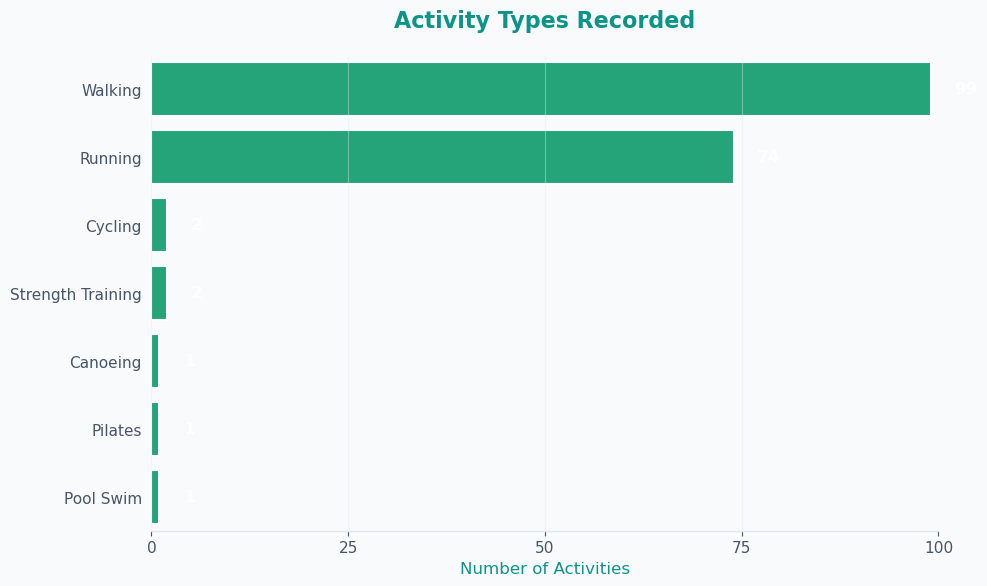

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Your data prep
counts = df['Activity Type'].value_counts().reset_index()
counts.columns = ['Activity Type', 'Count']
order = counts['Activity Type'].tolist()

# Set theme
plt.style.use('default')
plt.rcParams.update({'font.size': 11})

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#f8fafc')

# Theme bar color (emerald - meets target feel)
sns.barplot(data=counts, y='Activity Type', x='Count', 
            order=order, color='#10b981', 
            edgecolor='white', linewidth=1.5, ax=ax)

# White labels (high contrast pre-attentive pop)
offset = counts['Count'].max() * 0.03
for i, row in enumerate(counts.itertuples()):
    ax.text(row.Count + offset, i, f'{int(row.Count)}', 
            va='center', ha='left', fontweight='bold', 
            color='white', fontsize=12)

# Clean axes (your style + theme)
ax.set_xticks([0, 25, 50, 75, 100 ])
# ax.set_xlim(0, counts['Count'].max() * 1.15)
ax.set_xlim(0, 100)

# Theory-aligned styling
ax.set_facecolor('#f8fafc')  # Consistent neutral surface
sns.despine(ax=ax, left=True, bottom=False)  # Your clean spines
ax.tick_params(axis='y', which='both', left=False)  # Your no y ticks
ax.tick_params(colors="#475569")  # Subtle ticks

# Theme colors (teal main)
ax.spines['bottom'].set_color('#e2e8f0')
ax.spines['bottom'].set_linewidth(1)
ax.xaxis.label.set_color('#0d9488')
ax.title.set_color('#0d9488')

# Grid for grouping (Gestalt continuity)
ax.grid(axis='x', alpha=0.4, color='#e2e8f0', linewidth=0.8)

# Labels/titles
ax.set_ylabel('')
ax.set_xlabel('Number of Activities', fontsize=12)
ax.set_title('Activity Types Recorded', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [9]:
## Q2 

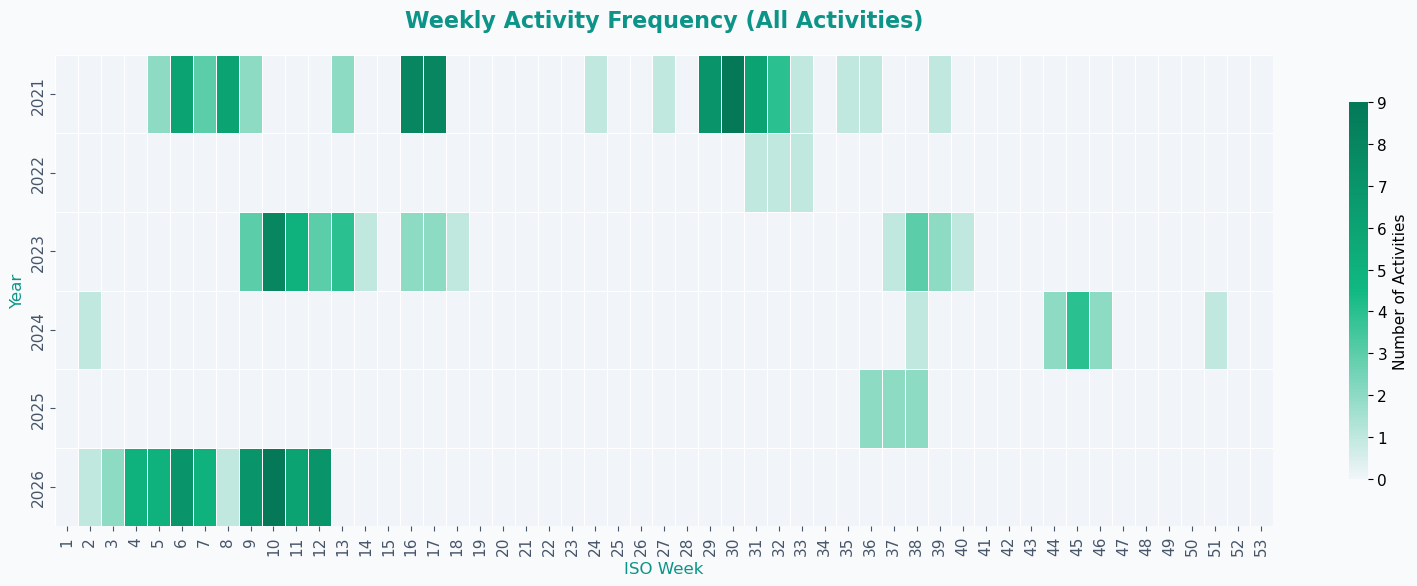

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# Set consistent theme
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 1.2,
    'grid.linestyle': '--',
    'grid.alpha': 0.3
})

# **ALL activities** count per week
weekly_count = df.groupby(["Year", "Week"]).size().reset_index(name="Activity_Count")
pivot_count = weekly_count.pivot(index="Year", columns="Week", values="Activity_Count")
pivot_count = pivot_count.reindex(columns=range(1, 54)).fillna(0).astype(float)

# YOUR exact colors: grey → #10b981 → #047857
colors = ["#f1f5f9", "#10b981", "#047857"]
n_bins = 256
cmap = LinearSegmentedColormap.from_list("your_green_gradient", colors, N=n_bins)

# Plot
fig, ax = plt.subplots(figsize=(16, 6), facecolor='#f8fafc')
sns.heatmap(
    pivot_count, cmap=cmap, ax=ax,
    linewidths=0.6, linecolor="white",
    vmin=0, vmax=pivot_count.max().max(),
    cbar_kws={
        "label": "Number of Activities",
        "shrink": 0.8
    }
)

# Theme styling
ax.set_title("Weekly Activity Frequency (All Activities)", fontsize=16, fontweight="bold", color="#0d9488", pad=20)
ax.set_xlabel("ISO Week", fontsize=12, color="#0d9488")
ax.set_ylabel("Year", fontsize=12, color="#0d9488")
ax.tick_params(axis='x', colors="#475569")
ax.tick_params(axis='y', colors="#475569")

plt.tight_layout()
plt.show()

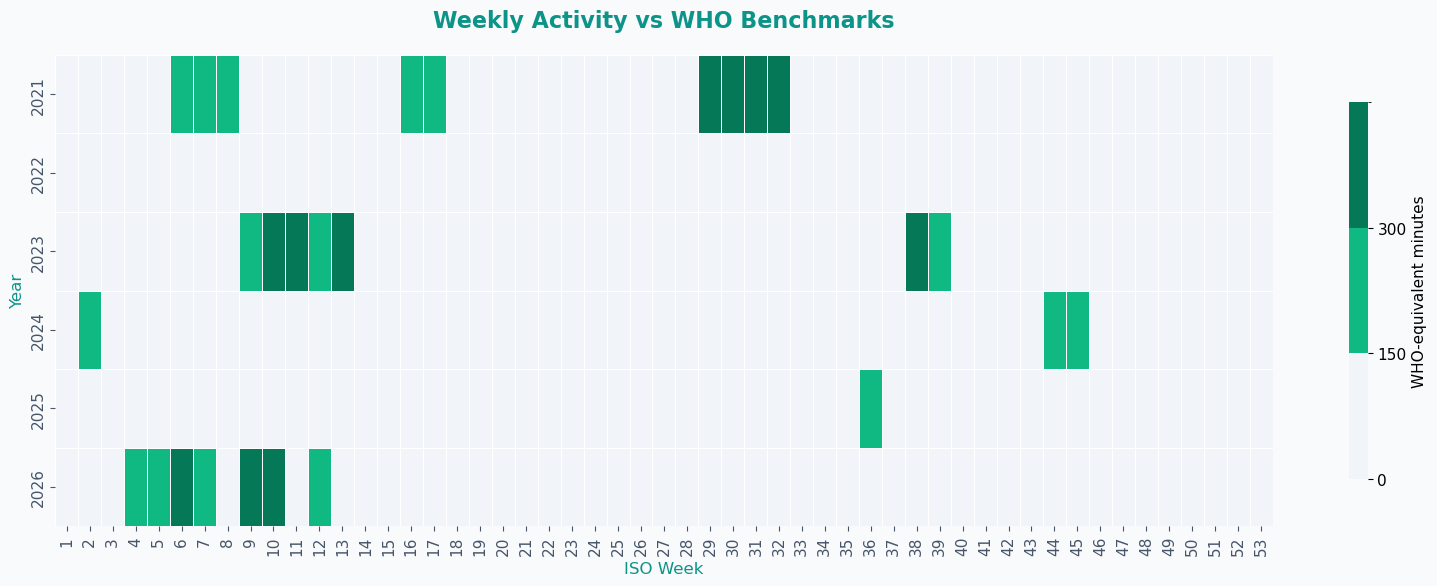

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm

# Set consistent theme
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 1.2,
    'grid.linestyle': '--',
    'grid.alpha': 0.3
})

# Your data prep
heatmap_df = df[df["Activity_Group"] == "Endurance"].copy()
weekly_intensity = heatmap_df.groupby(["Year", "Week"])["WHO_equiv"].sum().reset_index()
pivot = weekly_intensity.pivot(index="Year", columns="Week", values="WHO_equiv")
pivot = pivot.reindex(columns=range(1, 54)).fillna(0)

# 3-level theme colors
colors = ["#f1f5f9", "#10b981", "#047857"]  # low → meet → exceed
bounds = [0, 150, 300, pivot.max().max() + 1]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# Plot
fig, ax = plt.subplots(figsize=(16, 6), facecolor='#f8fafc')
sns.heatmap(
    pivot, cmap=cmap, norm=norm, ax=ax,
    linewidths=0.6, linecolor="white",
    cbar_kws={
        "label": "WHO-equivalent minutes",
        "ticks": [0, 150, 300],
        "shrink": 0.8
    }
)

# Theme styling
ax.set_title("Weekly Activity vs WHO Benchmarks", fontsize=16, fontweight="bold", color="#0d9488", pad=20)
ax.set_xlabel("ISO Week", fontsize=12, color="#0d9488")
ax.set_ylabel("Year", fontsize=12, color="#0d9488")
ax.tick_params(axis='x', colors="#475569")
ax.tick_params(axis='y', colors="#475569")

plt.tight_layout()
plt.show()

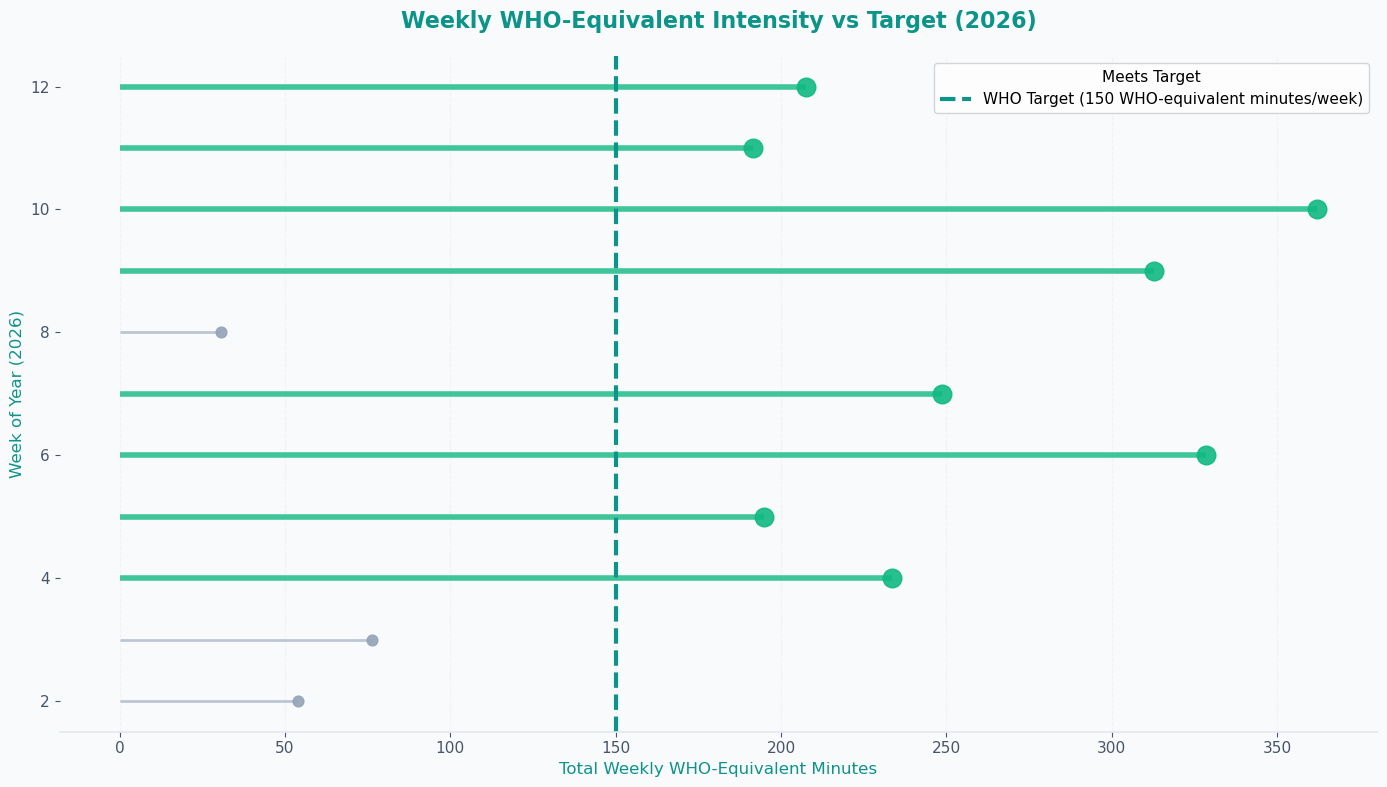

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter to 2026 only, use WHO_equiv
weekly_intensity_2026 = df[df["Year"] == 2026].groupby(["Year", "Week"], as_index=False)["WHO_equiv"].sum()
weekly_intensity_2026["Enough"] = weekly_intensity_2026["WHO_equiv"] >= 150

fig, ax = plt.subplots(figsize=(14, 8), facecolor="#f8fafc")

# Dots first: green for success, gray for failure
for idx, row in weekly_intensity_2026.iterrows():
    color = "#10b981" if row["Enough"] else "#94a3b8"
    size = 180 if row["Enough"] else 60
    ax.scatter(row["WHO_equiv"], row["Week"], 
               s=size, color=color, alpha=0.9, zorder=3)

# Lines: thick green for success, medium gray for failure
for idx, row in weekly_intensity_2026.iterrows():
    line_color = "#10b981" if row["Enough"] else "#94a3b8"
    line_width = 4 if row["Enough"] else 2
    alpha = 0.8 if row["Enough"] else 0.6
    
    ax.hlines(y=row["Week"], xmin=0, xmax=row["WHO_equiv"], 
              color=line_color, linewidth=line_width, alpha=alpha)

# WHO target
ax.axvline(150, color="#0d9488", lw=3, ls="--", 
           label="WHO Target (150 WHO-equivalent minutes/week)")

# Theme
ax.set_facecolor("#f8fafc")
ax.tick_params(colors="#475569")
sns.despine(ax=ax, left=True)
ax.spines['bottom'].set_color('#e2e8f0')
ax.grid(axis="x", alpha=0.4, color="#e2e8f0")

ax.set_xlabel("Total Weekly WHO-Equivalent Minutes", fontsize=12, color="#0d9488")
ax.set_ylabel("Week of Year (2026)", fontsize=12, color="#0d9488")
ax.set_title("Weekly WHO-Equivalent Intensity vs Target (2026)", 
             fontsize=16, fontweight="bold", color="#0d9488", pad=20)
ax.legend(title="Meets Target", loc="upper right")

plt.tight_layout()
plt.show()

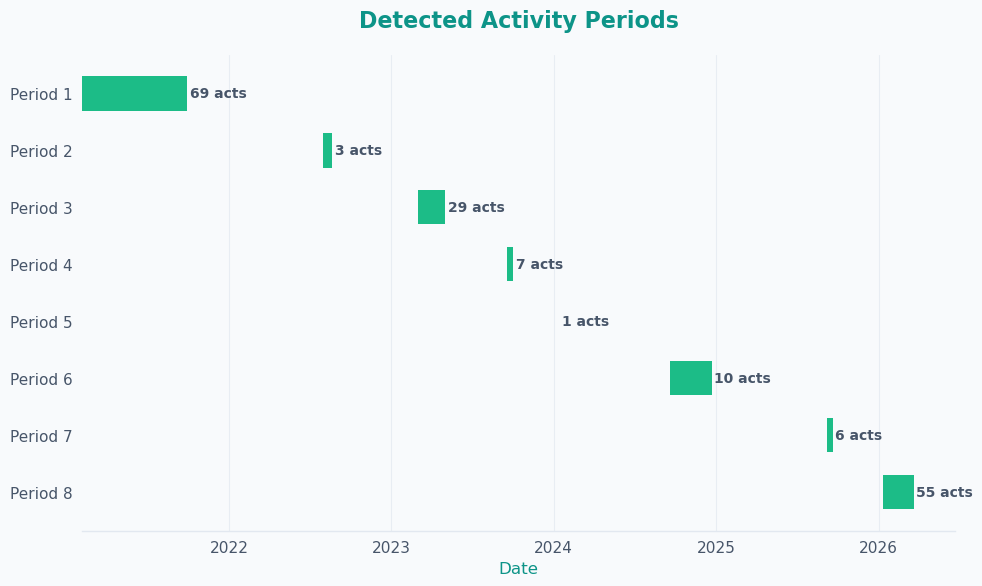

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# -----------------------------
# 1. Build activity periods
# -----------------------------
period_df = df.copy()
period_df["Date"] = pd.to_datetime(period_df["Date"])
period_df = period_df.sort_values("Date").reset_index(drop=True)

# Gap in days between activities
period_df["Gap_Days"] = period_df["Date"].diff().dt.days

# New period if first activity or gap > 60 days
period_df["New_Period"] = period_df["Gap_Days"].isna() | (period_df["Gap_Days"] > 60)

# Assign period id
period_df["Period_ID"] = period_df["New_Period"].cumsum()

# Summarise each period
period_summary = (
    period_df.groupby("Period_ID")
    .agg(
        Start_Date=("Date", "min"),
        End_Date=("Date", "max"),
        Activities=("Date", "count"),
        Total_WHO_equiv=("WHO_equiv", "sum")
    )
    .reset_index()
)

period_summary["Duration_Days"] = (
    period_summary["End_Date"] - period_summary["Start_Date"]
).dt.days + 1

period_summary = period_summary.sort_values("Start_Date").reset_index(drop=True)
period_summary["Period_Label"] = [f"Period {i}" for i in range(1, len(period_summary) + 1)]

# -----------------------------
# 2. Plot with notebook theme
# -----------------------------
sns.set_style("white")

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")

for i, row in period_summary.iterrows():
    start_num = mdates.date2num(row["Start_Date"])
    duration = row["Duration_Days"]

    ax.barh(
        y=i,
        width=duration,
        left=start_num,
        height=0.6,
        color="#10b981",
        edgecolor="none",
        alpha=0.95
    )

    # Label at the end of each bar
    ax.text(
        start_num + duration + 5,
        i,
        f'{row["Activities"]} acts',
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#475569"
    )

# Y labels
ax.set_yticks(range(len(period_summary)))
ax.set_yticklabels(period_summary["Period_Label"])

# Date axis formatting
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

# Style to match other charts
ax.grid(axis="x", linestyle="-", linewidth=0.8, color="#e2e8f0", alpha=0.7)
sns.despine(ax=ax, left=True)

ax.tick_params(axis="y", which="both", left=False, labelleft=True, colors="#475569")
ax.tick_params(axis="x", colors="#475569")

ax.spines["bottom"].set_color("#e2e8f0")
ax.spines["bottom"].set_linewidth(1.0)

ax.set_xlabel("Date", fontsize=12, color="#0d9488")
ax.set_ylabel("")
ax.set_title("Detected Activity Periods", fontsize=16, fontweight="bold", color="#0d9488", pad=20)

# Earliest period at top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

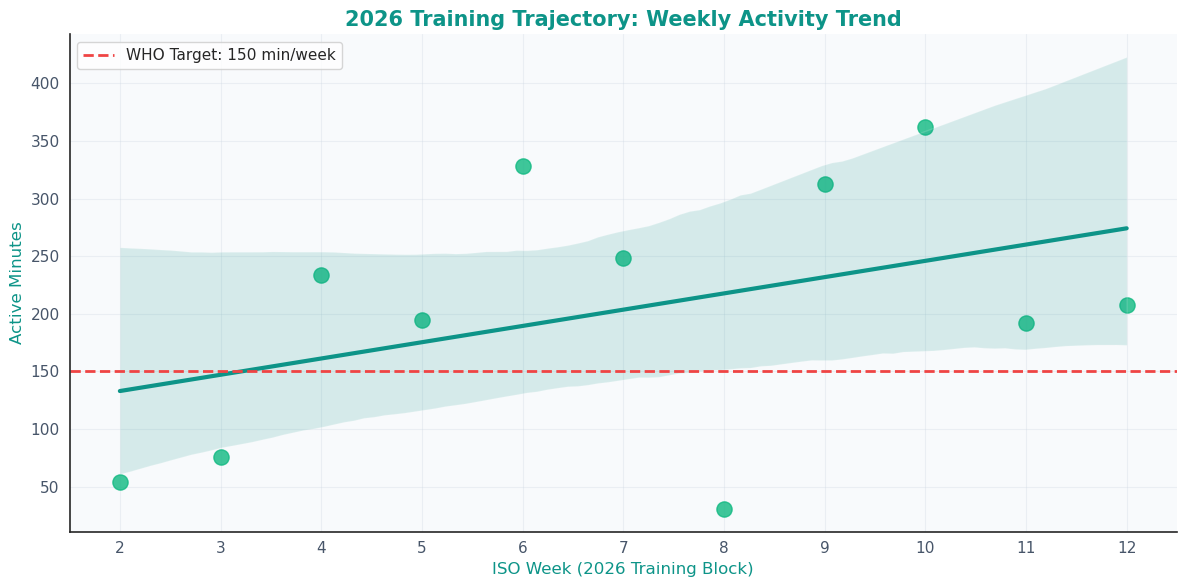

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week

recent_2026 = df[df['Year'] == 2026].copy()
weekly_trend = recent_2026.groupby('Week')['WHO_equiv'].sum().reset_index()
weekly_trend['Week_Seq'] = range(1, len(weekly_trend) + 1)

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("#f8fafc")

sns.regplot(
    data=weekly_trend,
    x='Week_Seq',
    y='WHO_equiv',
    scatter_kws={'s': 120, 'alpha': 0.8, 'color': '#10b981'},
    line_kws={'color': '#0d9488', 'lw': 3},
    ax=ax
)

ax.axhline(150, color='#ef4444', lw=2, ls='--', label='WHO Target: 150 min/week')

ax.set_xticks(weekly_trend['Week_Seq'])
ax.set_xticklabels(weekly_trend['Week'])

ax.set_xlabel('ISO Week (2026 Training Block)', fontsize=12, color="#0d9488")
ax.set_ylabel('Active Minutes', fontsize=12, color="#0d9488")
ax.set_title(
    '2026 Training Trajectory: Weekly Activity Trend',
    fontsize=15,
    fontweight='bold',
    color="#0d9488"
)

ax.legend()
ax.grid(axis='both', alpha=0.3, color="#cbd5e1")
sns.despine(ax=ax)
ax.tick_params(colors="#475569")

plt.tight_layout()
plt.show()

In [30]:
import requests

url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-communities.geojson"
r = requests.get(url, timeout=30)
r.raise_for_status()

with open("spain_communities.geojson", "w", encoding="utf-8") as f:
    f.write(r.text)

print("GeoJSON saved successfully.")

GeoJSON saved successfully.


In [38]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import json

pio.renderers.default = "notebook_connected"

# --------------------------------------------------
# Your data
# --------------------------------------------------
bad_locations = {"Walking", "Running", "Cycling", "Swimming", "Pool", "Treadmill"}
spain_df = df[df["Location"].notna() & ~df["Location"].isin(bad_locations)].copy()

community_map = {
    "Majadahonda": "Community of Madrid",
    "Pozuelo de Alarcón": "Community of Madrid",
    "Boadilla del Monte": "Community of Madrid",
    "Las Rozas de Madrid": "Community of Madrid",
    "Madrid": "Community of Madrid",
    "Alcobendas": "Community of Madrid",
    "Villanueva de la Cañada": "Community of Madrid",
    "Rascafría": "Community of Madrid",
    "Sanxenxo": "Galicia",
    "Gijón": "Asturias",
    "Villaviciosa": "Asturias",
    "Ribadesella": "Asturias",
    "El Vendrell": "Catalonia",
}

spain_df["Comunidad"] = spain_df["Location"].map(community_map)
spain_df = spain_df[spain_df["Comunidad"].notna()].copy()

community_counts = (
    spain_df.groupby("Comunidad", as_index=False)
    .size()
    .rename(columns={"size": "Activity_Count"})
)

# --------------------------------------------------
# Exact GeoJSON matches
# --------------------------------------------------
name_map = {
    "Community of Madrid": "Madrid",
    "Galicia": "Galicia",
    "Asturias": "Asturias",
    "Catalonia": "Cataluña"
}

community_counts["geo_name"] = community_counts["Comunidad"].map(name_map)
community_counts = community_counts[community_counts["geo_name"].notna()].copy()

# --------------------------------------------------
# Load local GeoJSON
# --------------------------------------------------
with open("spain_communities.geojson", "r", encoding="utf-8") as f:
    spain_geojson = json.load(f)

# --------------------------------------------------
# Choropleth map
# --------------------------------------------------
fig = px.choropleth_map(
    community_counts,
    geojson=spain_geojson,
    locations="geo_name",
    featureidkey="properties.name",
    color="Activity_Count",
    hover_name="Comunidad",
    hover_data={"Activity_Count": True, "geo_name": False},
    color_continuous_scale=[
        [0.00, "#ecfdf5"],
        [0.35, "#a7f3d0"],
        [0.70, "#10b981"],
        [1.00, "#047857"]
    ],
    map_style="carto-positron-nolabels",
    center={"lat": 40.3, "lon": -3.7},
    zoom=4.6,
    opacity=0.85,
    title="Activities by Autonomous Community"
)

fig.update_traces(
    marker_line_color="#e2e8f0",
    marker_line_width=1.5,
    hovertemplate="<b>%{hovertext}</b><br>Activities: %{z}<extra></extra>"
)

# --------------------------------------------------
# Labels outside regions for readability
# --------------------------------------------------
label_positions = pd.DataFrame({
    "Comunidad": ["Community of Madrid", "Galicia", "Asturias", "Catalonia"],
    "lat": [39.82, 43.15, 43.82, 41.40],
    "lon": [-3.62, -10.05, -5.70, 3.35]
})

label_positions = label_positions[
    label_positions["Comunidad"].isin(community_counts["Comunidad"])
].copy()

fig.add_trace(
    go.Scattermap(
        lon=label_positions["lon"],
        lat=label_positions["lat"],
        text=label_positions["Comunidad"],
        mode="text",
        textfont=dict(size=12, color="#475569"),
        textposition="middle center",
        hoverinfo="skip",
        showlegend=False
    )
)

fig.update_layout(
    paper_bgcolor="#f8fafc",
    plot_bgcolor="#f8fafc",
    font=dict(color="#475569", size=11),
    title=dict(font=dict(size=16, color="#0d9488")),
    coloraxis_colorbar=dict(
        title="Activity Count",
        bgcolor="#f8fafc",
        tickfont=dict(color="#475569")
    ),
    margin=dict(l=10, r=10, t=55, b=10)
)

fig.show()

In [16]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook_connected"

# Madrid municipalities only
madrid_locations = {
    "Majadahonda": (40.4267, -3.8822),
    "Pozuelo de Alarcón": (40.4314, -3.8125),
    "Boadilla del Monte": (40.4092, -3.8828),
    "Las Rozas de Madrid": (40.4928, -3.8747),
    "Madrid": (40.4168, -3.7038),
    "Alcobendas": (40.5453, -3.6500),
    "Villanueva de la Cañada": (40.4469, -4.0000),
    "Rascafría": (40.9192, -3.7833)
}

# Filter data to Madrid locations
madrid_df = df[
    df["Location"].isin(list(madrid_locations.keys()))
].copy()

# Count per municipality (FIXED column names)
location_counts = madrid_df["Location"].value_counts().reset_index()
location_counts.columns = ["Location", "Activity_Count"]  # Explicit names

# Add coordinates
location_counts["lat"] = location_counts["Location"].map(
    {k: v[0] for k, v in madrid_locations.items()}
)
location_counts["lon"] = location_counts["Location"].map(
    {k: v[1] for k, v in madrid_locations.items()}
)

# Your notebook theme
fig = px.scatter_map(
    location_counts,
    lat="lat", lon="lon",
    size="Activity_Count",
    color="Activity_Count",
    color_continuous_scale=[[0, "#10b981"], [1, "#047857"]],
    hover_name="Location",
    hover_data={"Activity_Count": "|%{customdata[0]}"},
    size_max=45,
    zoom=9.5,
    center={"lat": 40.45, "lon": -3.85},
    map_style="carto-positron",
    title="Madrid Activities by Municipality"
)

fig.update_traces(
    mode="markers+text",
    text=location_counts["Location"],
    textposition="top center",
    marker=dict(opacity=0.9),
    textfont=dict(size=10, color="#475569"),
    hovertemplate="<b>%{hovertext}</b><br>Activities: %{customdata[0]}<extra></extra>"
)

fig.update_layout(
    paper_bgcolor="#f8fafc",
    plot_bgcolor="#f8fafc",
    font=dict(color="#475569", size=11),
    title=dict(font=dict(size=16, color="#0d9488")),
    coloraxis_colorbar=dict(
        title="Activity Count",
        bgcolor="#f8fafc",
        tickfont=dict(color="#475569")
    ),
    margin=dict(l=10, r=10, t=55, b=10),
    showlegend=False
)

fig.show()